# NLP Exercise: Spam Classification

## Objective

The goal of this exercise is to classify messages as either spam or ham using Natural Language Processing techniques. You will preprocess the text data, apply feature extraction methods, train a machine learning model, and evaluate its performance.

---

### Dataset link: [Spam classification dataset link](https://drive.google.com/file/d/1X8awBL7BvjblDLBWObCiW2xmiapLSXPC/view)

---

## Explanation of the Columns

- **Class**: The label indicating whether the message is ham (not spam) or spam.
- **Message**: The actual content of the message.

---

## Steps to Follow

### 1. Data Loading

1. Load the sample dataset into a Pandas DataFrame.
2. Inspect the first few rows to understand the structure of the data.
3. Check for any missing or null values and handle them appropriately.

### 2. Text Preprocessing

Preprocess the text data to make it suitable for machine learning:

1. **Lowercasing**: Convert all text to lowercase to ensure uniformity.
2. **Remove Punctuations and Special Characters**: Use regular expressions to clean the text.
3. **Stop Word Removal**: Eliminate common words (like "and", "the") that do not contribute much to the analysis.
4. **Tokenization**: Split the text into individual words or tokens.
5. **Lemmatization**: Reduce words to their base form to unify different word forms (e.g., "running" -> "run").

### 3. Feature Extraction

Convert the preprocessed text into a numerical format suitable for machine learning:

1. **Bag of Words (BoW)**: Create a matrix where each row represents a message and each column represents a word. The value in each cell is the count or frequency of the word in the respective message.
2. **(Optional) TF-IDF**: Apply Term Frequency-Inverse Document Frequency to highlight the importance of unique words in each message.

### 4. Model Training

1. Split the dataset into training and testing sets (e.g., 80% training, 20% testing).
2. Train a machine learning model:
    - Algorithms: Logistic Regression, Naive Bayes, or Random Forest.
3. Fit the model to the training data using the extracted features.

### 5. Prediction

1. Use the trained model to predict whether new messages are ham or spam.
2. Store the predictions for evaluation.

### 6. Evaluation

- **Confusion Matrix**: To understand how well the model correctly identifies spam and ham messages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading


In [2]:
df = pd.read_csv('Spam_SMS.csv')

df.head()

,Class,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Exploratory Data Analysis

In [3]:
df.shape

(5574, 2)

In [4]:
df['Class'].value_counts()

Class
ham     4827
spam     747
Name: count, dtype: int64

In [5]:
df['Class'].value_counts(normalize=True)

Class
ham     0.865985
spam    0.134015
Name: proportion, dtype: float64

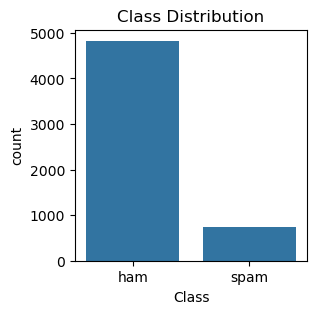

In [6]:
fig, ax = plt.subplots(figsize=(3,3))

ax.set_title("Class Distribution")
sns.countplot(data=df, x='Class')

plt.show()

### Visualizing the distribution of most frequent words

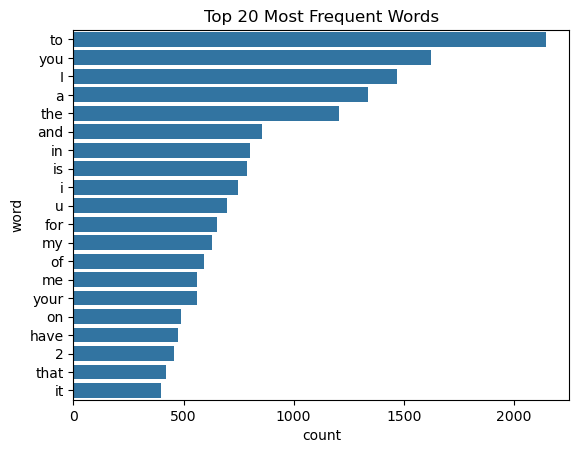

In [7]:
from collections import Counter

# Get all words in the text
all_words = " ".join(df['Message'].values).split()
word_counts = Counter(all_words)

# Get the most common words
common_words = word_counts.most_common(20)

# Convert to DataFrame for plotting
common_words_df = pd.DataFrame(common_words, columns=['word', 'count'])

# Plot the most common words
sns.barplot(data=common_words_df, x='count', y='word')
plt.title('Top 20 Most Frequent Words')
plt.show()

### Classwise WordCloud - Explore the Relationships between each pair of Inputs and Output

In [8]:
! pip install wordcloud

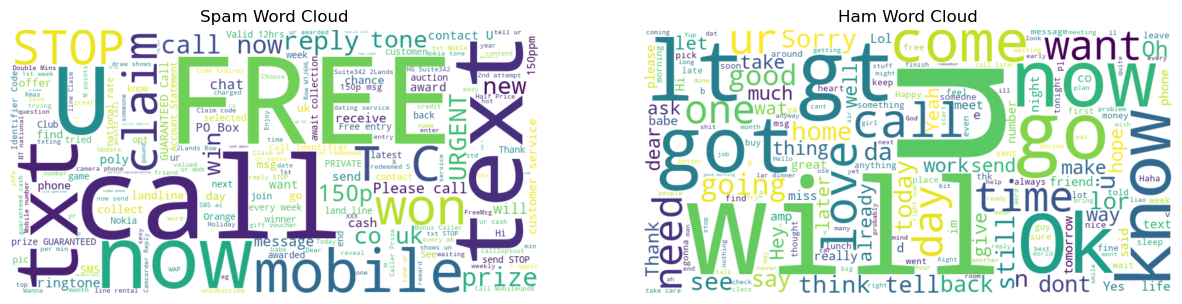

In [9]:
from wordcloud import WordCloud

# Word cloud for spam messages
spam_text = " ".join(df[df['Class'] == 'spam']['Message'].values)
spam_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(spam_text)

# Word cloud for ham messages
ham_text = " ".join(df[df['Class'] == 'ham']['Message'].values)
ham_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(ham_text)

# Display the word clouds
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].imshow(spam_wordcloud, interpolation='bilinear')
ax[0].axis('off')
ax[0].set_title('Spam Word Cloud')
ax[1].imshow(ham_wordcloud, interpolation='bilinear')
ax[1].axis('off')
ax[1].set_title('Ham Word Cloud')
plt.show()

**Segregate Inputs (X) and Output (y)**

In [10]:
y = df["Class"]
X = df[["Message"]]

## Split the data into Train and Test

In [11]:
# Splitting into train and test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(4459, 1) (4459,)
(1115, 1) (1115,)


### Text Preprocessing

In [12]:
!pip install nltk

In [13]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def clean(doc): 
    # doc is a string of text
    
    # Let's define a regex to match special characters and digits
    regex = "[^a-zA-Z.]"
    doc = re.sub(regex, " ", doc)

    # Convert to lowercase
    doc = doc.lower()
        
    # Tokenization
    tokens = nltk.word_tokenize(doc)

    # Stop word removal
    stop_words = list(set(stopwords.words('english')))
    custom_stop_words = ['Will', 'U']
    stop_words = stop_words + custom_stop_words
    filtered_tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]
    
    # Join and return
    return " ".join(lemmatized_tokens)

In [14]:
# !pip install tqdm

In [15]:
X_train

,Message
1350,FREE2DAY sexy St George's Day pic of Jordan!Tx...
5544,Armand says get your ass over to epsilon
1168,Lol now I'm after that hot air balloon!
5551,"You know, wot people wear. T shirts, jumpers, ..."
5320,"Good morning, my Love ... I go to sleep now an..."
...,...
3772,"Hi, wlcome back, did wonder if you got eaten b..."
5191,ree entry in 2 a weekly comp for a chance to w...
5226,"""OH FUCK. JUSWOKE UP IN A BED ON A BOATIN THE ..."
5390,NOT MUCH NO FIGHTS. IT WAS A GOOD NITE!!


In [16]:

def clean(doc):
    return doc.strip().lower()

X_train['clean_text'] = X_train['Message'].apply(lambda doc: clean(doc))

# Display the first few rows to check the result
X_train.head()


,Message,clean_text
1350,FREE2DAY sexy St George's Day pic of Jordan!Tx...,free2day sexy st george's day pic of jordan!tx...
5544,Armand says get your ass over to epsilon,armand says get your ass over to epsilon
1168,Lol now I'm after that hot air balloon!,lol now i'm after that hot air balloon!
5551,"You know, wot people wear. T shirts, jumpers, ...","you know, wot people wear. t shirts, jumpers, ..."
5320,"Good morning, my Love ... I go to sleep now an...","good morning, my love ... i go to sleep now an..."


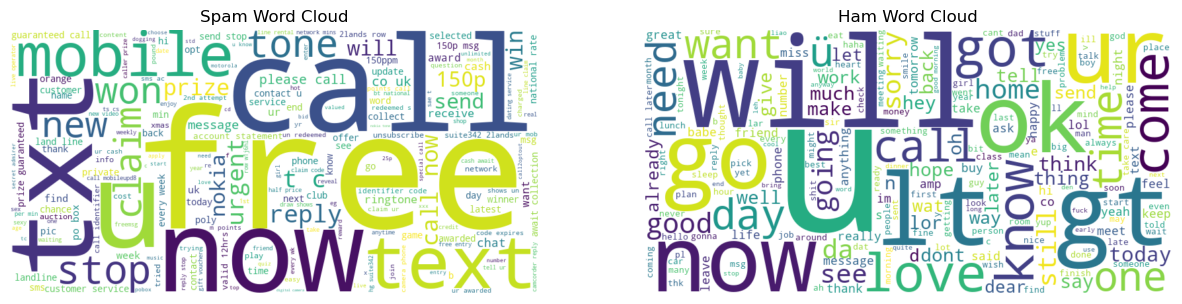

In [17]:
# Word cloud for spam messages
spam_text = " ".join(X_train[y_train == 'spam']['clean_text'].values)
spam_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(spam_text)

# Word cloud for ham messages
ham_text = " ".join(X_train[y_train == 'ham']['clean_text'].values)
ham_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(ham_text)

# Display the word clouds
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].imshow(spam_wordcloud, interpolation='bilinear')
ax[0].axis('off')
ax[0].set_title('Spam Word Cloud')
ax[1].imshow(ham_wordcloud, interpolation='bilinear')
ax[1].axis('off')
ax[1].set_title('Ham Word Cloud')
plt.show()

In [18]:
df

,Class,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5569,spam,This is the 2nd time we have tried 2 contact u...
5570,ham,Will ü b going to esplanade fr home?
5571,ham,"Pity, * was in mood for that. So...any other s..."
5572,ham,The guy did some bitching but I acted like i'd...


In [19]:
# Bag of Words
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the "CountVectorizer" object, which is scikit-learn's
# bag of words tool.
bow_vect = CountVectorizer()

# fit_transform() does two functions: 
# First, it fits and learns the vocabulary 
# Second, it transforms our training data into feature vectors
# The input to fit_transform should be a list of strings
dtm = bow_vect.fit_transform(df['Message'])

print(f"Shape of DTM (# of docs, # of unique vocabulary): {dtm.shape}")

print(f"Type of DTM (i.e. Compressed Sparse Row (CSR) format): {type(dtm)}")

Shape of DTM (# of docs, # of unique vocabulary): (5574, 8713)
Type of DTM (i.e. Compressed Sparse Row (CSR) format): <class 'scipy.sparse._csr.csr_matrix'>


In [20]:
# We can look at unique words by using 'vocabulary_'

print(f"Vocabulary size: {len(bow_vect.vocabulary_)}")
print()
print(f"Let's look at the vocabulary stored in the object: \n{bow_vect.vocabulary_}")
print()
print("Output Feature Names:", bow_vect.get_feature_names_out())

Vocabulary size: 8713

Let's look at the vocabulary stored in the object: 
{'go': 3571, 'until': 8085, 'jurong': 4374, 'point': 5958, 'crazy': 2338, 'available': 1316, 'only': 5571, 'in': 4114, 'bugis': 1767, 'great': 3655, 'world': 8549, 'la': 4501, 'buffet': 1765, 'cine': 2061, 'there': 7694, 'got': 3615, 'amore': 1082, 'wat': 8325, 'ok': 5538, 'lar': 4537, 'joking': 4342, 'wif': 8451, 'oni': 5567, 'free': 3373, 'entry': 2963, 'wkly': 8507, 'comp': 2178, 'to': 7806, 'win': 8464, 'fa': 3100, 'cup': 2398, 'final': 3221, 'tkts': 7793, '21st': 412, 'may': 4959, '2005': 403, 'text': 7644, '87121': 794, 'receive': 6340, 'question': 6232, 'std': 7279, 'txt': 7986, 'rate': 6284, 'apply': 1169, '08452810075over18': 77, 'dun': 2815, 'say': 6679, 'so': 7074, 'early': 2836, 'hor': 3952, 'already': 1054, 'then': 7688, 'nah': 5270, 'don': 2724, 'think': 7709, 'he': 3805, 'goes': 3579, 'usf': 8131, 'lives': 4692, 'around': 1220, 'here': 3856, 'though': 7729, 'freemsg': 3380, 'hey': 3866, 'darling':

In [21]:
# Converting the sparse matrix to a dataframe

bow_df = pd.DataFrame(dtm.toarray(), 
             columns=bow_vect.get_feature_names_out())

In [22]:
bow_df.head()

,00,000,000pes,008704050406,0089,0121,01223585236,01223585334,0125698789,02,...,zeros,zhong,zindgi,zoe,zogtorius,zoom,zouk,zyada,èn,ú1
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Generating Word2Vec Representations

**Step 1** - Convert the sentences to the List of Words (i.e. List of Tokens)  
**Step 2** - Import `Word2Vec` module from `gensim.models`  
**Step 3** - Use Word2Vec to learn numerical vectors for each unique words. Word2Vec uses the list of tokens and generate 300Dimensional numerical vector for each unique word.  
**Step 4** - Convert the word vectors to document vectors.

In [23]:
X_train.head()

,Message,clean_text
1350,FREE2DAY sexy St George's Day pic of Jordan!Tx...,free2day sexy st george's day pic of jordan!tx...
5544,Armand says get your ass over to epsilon,armand says get your ass over to epsilon
1168,Lol now I'm after that hot air balloon!,lol now i'm after that hot air balloon!
5551,"You know, wot people wear. T shirts, jumpers, ...","you know, wot people wear. t shirts, jumpers, ..."
5320,"Good morning, my Love ... I go to sleep now an...","good morning, my love ... i go to sleep now an..."


In [24]:
# Converting the sentences to the List of Words (i.e. List of Tokens)

X_train['tokenised_sentences'] = X_train['clean_text'].apply(lambda doc : doc.split())

X_train.head()

,Message,clean_text,tokenised_sentences
1350,FREE2DAY sexy St George's Day pic of Jordan!Tx...,free2day sexy st george's day pic of jordan!tx...,"[free2day, sexy, st, george's, day, pic, of, j..."
5544,Armand says get your ass over to epsilon,armand says get your ass over to epsilon,"[armand, says, get, your, ass, over, to, epsilon]"
1168,Lol now I'm after that hot air balloon!,lol now i'm after that hot air balloon!,"[lol, now, i'm, after, that, hot, air, balloon!]"
5551,"You know, wot people wear. T shirts, jumpers, ...","you know, wot people wear. t shirts, jumpers, ...","[you, know,, wot, people, wear., t, shirts,, j..."
5320,"Good morning, my Love ... I go to sleep now an...","good morning, my love ... i go to sleep now an...","[good, morning,, my, love, ..., i, go, to, sle..."


In [ ]:
!pip install gensim

In [ ]:
from gensim.models import Word2Vec

%time word2vec_vect = Word2Vec(X_train['tokenised_sentences'], vector_size=300, min_count=1)

print(word2vec_vect)

In [ ]:
# We can check out what is learned by "word2vec_vect"

print(f"Number of documents used for Training: {word2vec_vect.corpus_count}")
print()
print(f"Vocabulary size: {len(word2vec_vect.wv.index_to_key)}")
print()
print(f"Vector Size: {word2vec_vect.vector_size}")

In [ ]:
def get_document_vector(doc, model):
    """Remove out-of-vocabulary words. 
    Create document vectors by averaging word vectors."""
    tokens = [word for word in doc if word in model]
    if tokens:
        doc_embedding = np.mean(model[tokens], axis=0)
    else:
        doc_embedding = np.zeros(model.vector_size)
    return doc_embedding

In [ ]:
X_train['w2v_doc_embeddings'] = X_train["tokenised_sentences"].apply(lambda doc : get_document_vector(doc, word2vec_vect.wv))

X_train.head()

### Visualizing Text Embeddings

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

embeddings = np.array(X_train['w2v_doc_embeddings'].tolist())

# Standardize the Embeddings
scaler = StandardScaler()
scaled_embeddings = scaler.fit_transform(embeddings)

# Convert target to numerical representations
labels = y_train.apply(lambda x : 1 if x=='ham' else 0)

pca = PCA(n_components = 2)
pca_data = pca.fit_transform(scaled_embeddings)

pca_df = pd.DataFrame(data=pca_data, columns=("Dim_1", "Dim_2"))
pca_df["labels"] = labels

plt.scatter(pca_df['Dim_1'], pca_df['Dim_2'], c=pca_df['labels'])
plt.show()

#### Apply Data Preparation on Test Data



In [ ]:
df.head()

In [ ]:
X_test['clean_text'] = X_test['Message'].apply(lambda doc: clean(doc))

X_test.head()

In [ ]:
X_test['tokenised_sentences'] = X_test['clean_text'].apply(lambda doc : doc.split())

X_test.head()

In [ ]:
X_test['w2v_doc_embeddings'] = X_test["tokenised_sentences"].apply(lambda doc : get_document_vector(doc, word2vec_vect.wv))

X_test.head()

## Model Training Training 

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc


# Building the Model
classifier = LogisticRegression()
%time classifier.fit(list(X_train["w2v_doc_embeddings"]), y_train)

# Predicting on unseen data
y_test_pred = classifier.predict(list(X_test["w2v_doc_embeddings"]))


### Model Evaluation from Logistic Regression

In [ ]:
y_test_pred

In [ ]:
y_test

In [ ]:
# Evaluation Metrics
accuracy_lr = accuracy_score(y_test, y_test_pred)

conf_matrix_lr = confusion_matrix(y_test, y_test_pred)

# Displaying the evaluation metrics with explanations
print(f'Accuracy of Logistic Regression: {accuracy_lr:.4f}')

print(f'Confusion Matrix for Logistic Regression:\n{conf_matrix_lr}')

In [ ]:
# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

# Building the Model
classifier = DecisionTreeClassifier()
%time classifier.fit(list(X_train["w2v_doc_embeddings"]), y_train)

# Predicting on unseen data
y_test_pred = classifier.predict(list(X_test["w2v_doc_embeddings"]))


### Evaluation Metrics for Decision Tree

In [ ]:

accuracy_dt = accuracy_score(y_test, y_test_pred)
conf_matrix_dt = confusion_matrix(y_test, y_test_pred)

# Displaying the evaluation metrics with explanations
print(f'Accuracy of Decision Tree: {accuracy_dt:.4f}')
print(f'Confusion Matrix for Decision Tree:\n{conf_matrix_dt}')

In [ ]:
# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

# Building the Model
classifier = RandomForestClassifier()
%time classifier.fit(list(X_train["w2v_doc_embeddings"]), y_train)

# Predicting on unseen data
y_test_pred = classifier.predict(list(X_test["w2v_doc_embeddings"]))

# Model Evaluation
print()
print(f"Model's Accuracy: {metrics.accuracy_score(y_test, y_test_pred)}")

### Evaluation Metrics for Random Forest 

In [ ]:

accuracy_rf = accuracy_score(y_test, y_test_pred)
conf_matrix_rf = confusion_matrix(y_test, y_test_pred)

# Displaying the evaluation metrics with explanations
print(f'Accuracy of Random Forest: {accuracy_rf:.4f}')
print(f'Confusion Matrix for Random Forest:\n{conf_matrix_rf}')

In [ ]:
# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Model Comparison and Analysis

## 1. Model Performance Overview

### Logistic Regression
- **Accuracy:** 0.8556  
- **Confusion Matrix:**  
  | Predicted | Actual Positive | Actual Negative |
  |-----------|-----------------|-----------------|
  | **Positive** | 954             | 0               |
  | **Negative** | 161             | 0               |

### Decision Tree
- **Accuracy:** 0.9031  
- **Confusion Matrix:**  
  | Predicted | Actual Positive | Actual Negative |
  |-----------|-----------------|-----------------|
  | **Positive** | 902             | 52              |
  | **Negative** | 56              | 105             |

### Random Forest
- **Accuracy:** 0.9354  
- **Confusion Matrix:**  
  | Predicted | Actual Positive | Actual Negative |
  |-----------|-----------------|-----------------|
  | **Positive** | 951             | 3               |
  | **Negative** | 69              | 92              |

---

## 2. Observations

### Logistic Regression
- **Accuracy:** 85.56%
- **Confusion Matrix Analysis:**
  - True Positives: 954  
  - False Negatives: 161  
  - **No correct predictions for the negative class.**
- Indicates a strong bias toward predicting the positive class.

### Decision Tree
- **Accuracy:** 90.31%
- **Confusion Matrix Analysis:**
  - True Positives: 902  
  - True Negatives: 105  
  - False Positives: 52  
  - False Negatives: 56  
- Performs better than Logistic Regression with improved predictions for both classes.

### Random Forest
- **Accuracy:** 93.54%
- **Confusion Matrix Analysis:**
  - True Positives: 951  
  - True Negatives: 92  
  - False Positives: 3  
  - False Negatives: 69  
- Shows the best accuracy among the three models, with a strong balance in predictions.

---

## 3. Recommendations
- **Best Model:** The **Random Forest** model is the most accurate, with better-balanced predictions for both classes.
- **Next Steps:**
  - Conduct further evaluation with metrics like precision, recall, F1-score, and AUC-ROC to confirm the robustness of the Random Forest model.
  - Analyze feature importance from the Random Forest model to understand the key drivers of predictions.
  - Consider hyperparameter tuning for Decision Tree and Random Forest models to potentially enhance their performance further.

---

## 4. Conclusion
The **Random Forest model** is the most effective among the three, providing the highest accuracy and well-balanced predictions. It is recommended for deployment after additional validation and testing.
